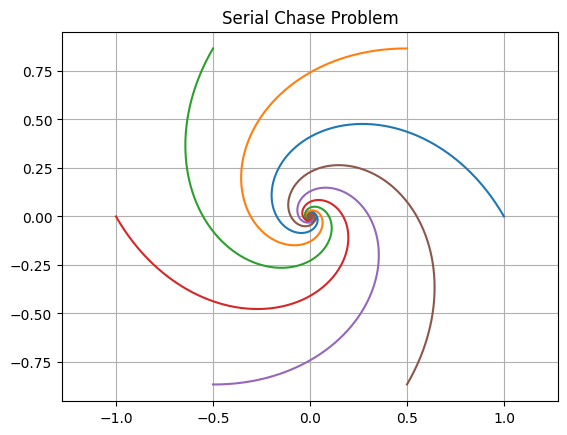

In [1]:
# Question:
# In the Serial Chase Problem, multiple entities are positioned on a circular path.
# Each entity chases the next one in the sequence.
#
# Task:
# 1. Initialize n entities equally spaced on a unit circle.
# 2. Each entity continuously moves toward the next one.
# 3. Update positions using a small time step (dt).
# 4. Simulate until convergence or maximum iterations.
# 5. Visualize the trajectories.

import numpy as np
import matplotlib.pyplot as plt

# Parameters
n = 6               # number of entities
dt = 0.01           # time step
speed = 1           # constant speed
max_iter = 1000

# Initial positions on unit circle
theta = np.linspace(0, 2*np.pi, n, endpoint=False)
x = np.cos(theta)
y = np.sin(theta)

# Store trajectories
traj_x = [[xi] for xi in x]
traj_y = [[yi] for yi in y]

# Simulation
for _ in range(max_iter):

    new_x = x.copy()
    new_y = y.copy()

    for i in range(n):
        target = (i + 1) % n

        dx = x[target] - x[i]
        dy = y[target] - y[i]

        distance = np.sqrt(dx**2 + dy**2)

        if distance > 0:
            new_x[i] += speed * dt * dx / distance
            new_y[i] += speed * dt * dy / distance

    x = new_x
    y = new_y

    # Save trajectory
    for i in range(n):
        traj_x[i].append(x[i])
        traj_y[i].append(y[i])

    # Stop if all entities converge
    if np.max(np.sqrt((x - x[0])**2 + (y - y[0])**2)) < 0.01:
        break

# Plot trajectories
for i in range(n):
    plt.plot(traj_x[i], traj_y[i])

plt.scatter(x, y)
plt.title("Serial Chase Problem")
plt.axis('equal')
plt.grid(True)
plt.show()